### 6. (a) Use CNN to classify CIFAR-10 images and plot training/validation accuracy. 

In [1]:
!pip install torch torchvision


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 10.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/212.5 MB ? eta -:--:--
   ---------------------------------------- 2.4/212.5 MB 12.2 MB/s eta 0:00:18
    --------------------------------------- 4.7/212.5 MB 11.9 MB/s eta 0:00:18
   - -------------------------------------- 7.1/212.5 MB 11.8 MB/s eta 0:00:18
   - -------------------------------------- 9.7/212.5 MB 11.8 MB/s eta 0:00:18
   -- ------------------------------------- 12.1/212.5 MB 11.8 MB/s eta 0:00:17
   -- ------------------------------------- 14.4/212.5 MB 11.8 MB/s eta 0:00:17
   --- ------------------------------------ 17.0/212.5 MB 11.8 MB/s eta 0:00:17
   --- ------------------------------------ 19.4/212.5 MB 11.8 MB/s eta 0:00:17
   ---- ----------------------------------- 21.8/212.5 MB 11.9 MB/s eta 0:00:17
   ---- ----------------------------------- 24.4/212.5 MB 11.8 MB/s

  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Complete model training and testing
# CNN on CIFAR-10 Dataset using PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Data Preprocessing and Loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# 2. CNN Model Definition
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN().to(device)

# 3. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training the Model
train_loss_history = []
test_accuracy_history = []
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_loss_history.append(train_loss)

    # Evaluate on test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracy_history.append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

# 5. Plotting Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracy_history, label='Test Accuracy')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

# 6. Confusion Matrix
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=classes).plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# 7. Visualizing Predictions
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(test_loader)
images, labels = next(dataiter)

# Print images
imshow(torchvision.utils.make_grid(images[:4]))

100%|████████████████████████████████████████████████████████████████████████████████| 170M/170M [03:27<00:00, 822kB/s]


Epoch [1/10], Loss: 1.4014, Test Accuracy: 62.09%
Epoch [2/10], Loss: 1.0436, Test Accuracy: 66.95%
Epoch [3/10], Loss: 0.8988, Test Accuracy: 69.14%
Epoch [4/10], Loss: 0.7946, Test Accuracy: 71.56%
Epoch [5/10], Loss: 0.7095, Test Accuracy: 71.93%
Epoch [6/10], Loss: 0.6339, Test Accuracy: 73.23%
Epoch [7/10], Loss: 0.5641, Test Accuracy: 73.87%
Epoch [8/10], Loss: 0.5032, Test Accuracy: 74.30%
Epoch [9/10], Loss: 0.4518, Test Accuracy: 74.64%
Epoch [10/10], Loss: 0.3962, Test Accuracy: 74.80%


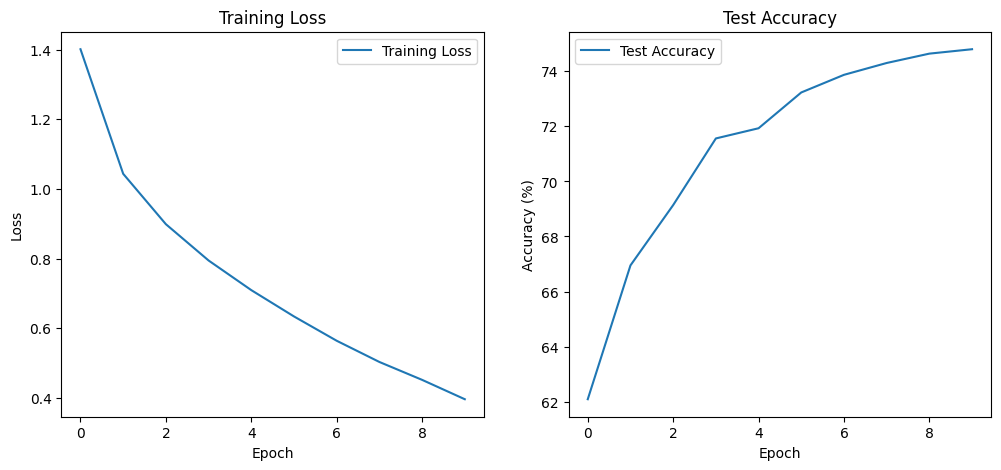

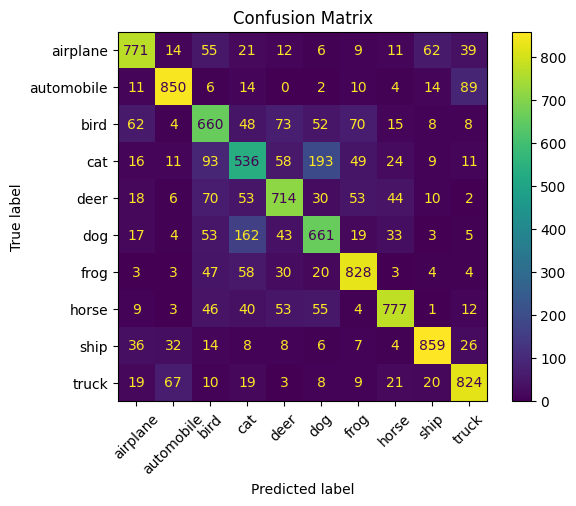

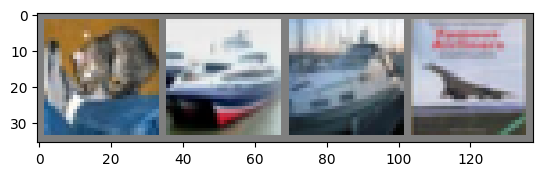

Predicted: cat ship ship airplane
Actual:    cat ship ship airplane


In [ ]:
# Print predicted labels
images = images.to(device)
outputs = model(images[:4])
_, predicted = torch.max(outputs, 1)

print("Predicted:", ' '.join(f'{classes[predicted[j]]}' for j in range(4)))
print("Actual:   ", ' '.join(f'{classes[labels[j]]}' for j in range(4)))